<a href="https://colab.research.google.com/github/gabriduarte2000-glitch/Trabalho-4---Processamento-de-sinais/blob/main/Aula_4_Tranformada_discreta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Comparação entre DTFT e DFT para o sinal $x[n] = \delta[n] - \delta[n-1] + \delta[n-2] - \delta[n-3]$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir o sinal x[n]
# x[n] = δ[n] − δ[n − 1] + δ[n − 2] − δ[n − 3]
# Isso significa que o sinal é [1, -1, 1, -1] para n=0, 1, 2, 3 e 0 para outros n.
# Para o cálculo da DFT, precisamos de um vetor finito que represente esses valores.
x = np.array([1, -1, 1, -1])

print("Sinal x[n]:", x)

Sinal x[n]: [ 1 -1  1 -1]


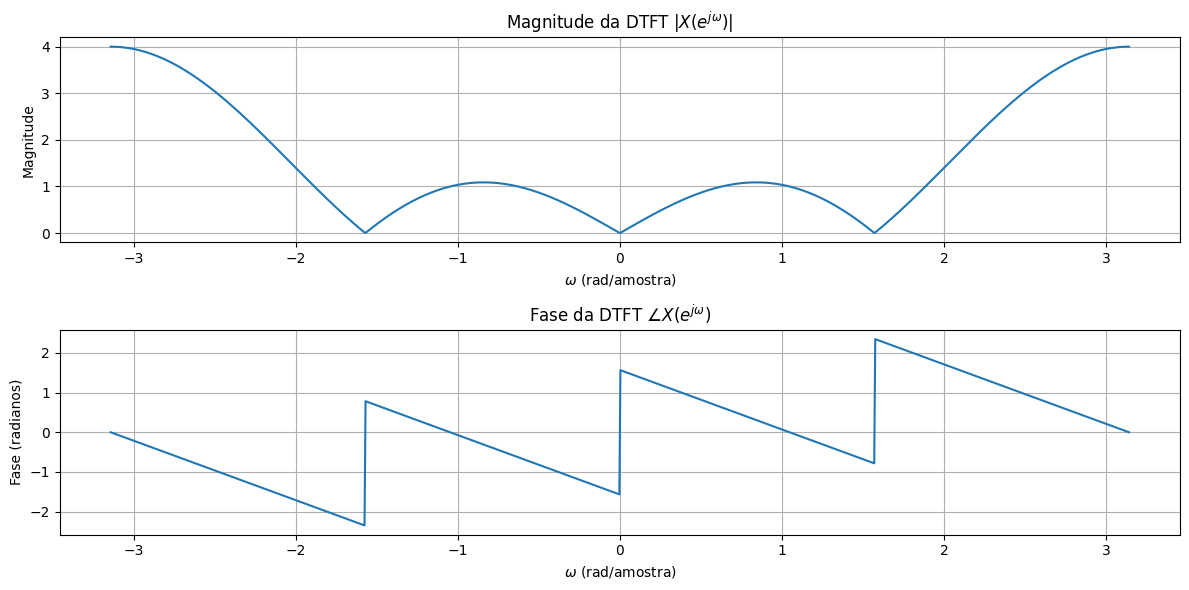

In [4]:
# Função para calcular a DTFT analítica
def dtft_analytic(omega):
    return 1 - np.exp(-1j * omega) + np.exp(-2j * omega) - np.exp(-3j * omega)

# Gerar um range de valores para ω (de -π a π)
omega_values = np.linspace(-np.pi, np.pi, 1000)
dtft_result = dtft_analytic(omega_values)

# Plotar Magnitude e Fase da DTFT
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(omega_values, np.abs(dtft_result))
plt.title(r'Magnitude da DTFT $ |X(e^{j\omega})| $')
plt.xlabel(r'$\omega$ (rad/amostra)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(omega_values, np.angle(dtft_result))
plt.title(r'Fase da DTFT $ \angle X(e^{j\omega}) $')
plt.xlabel(r'$\omega$ (rad/amostra)')
plt.ylabel('Fase (radianos)')
plt.grid(True)

plt.tight_layout()
plt.show()

### 3. Calcular e Comparar a DFT com a DTFT para $N \in \{4, 16, 64, 1024\}$

A DFT é dada por $X[k] = \sum_{n=0}^{N-1} x[n] e^{-j2\pi kn/N}$ para $k = 0, 1, \dots, N-1$.

Usaremos `numpy.fft.fft` para calcular a DFT.

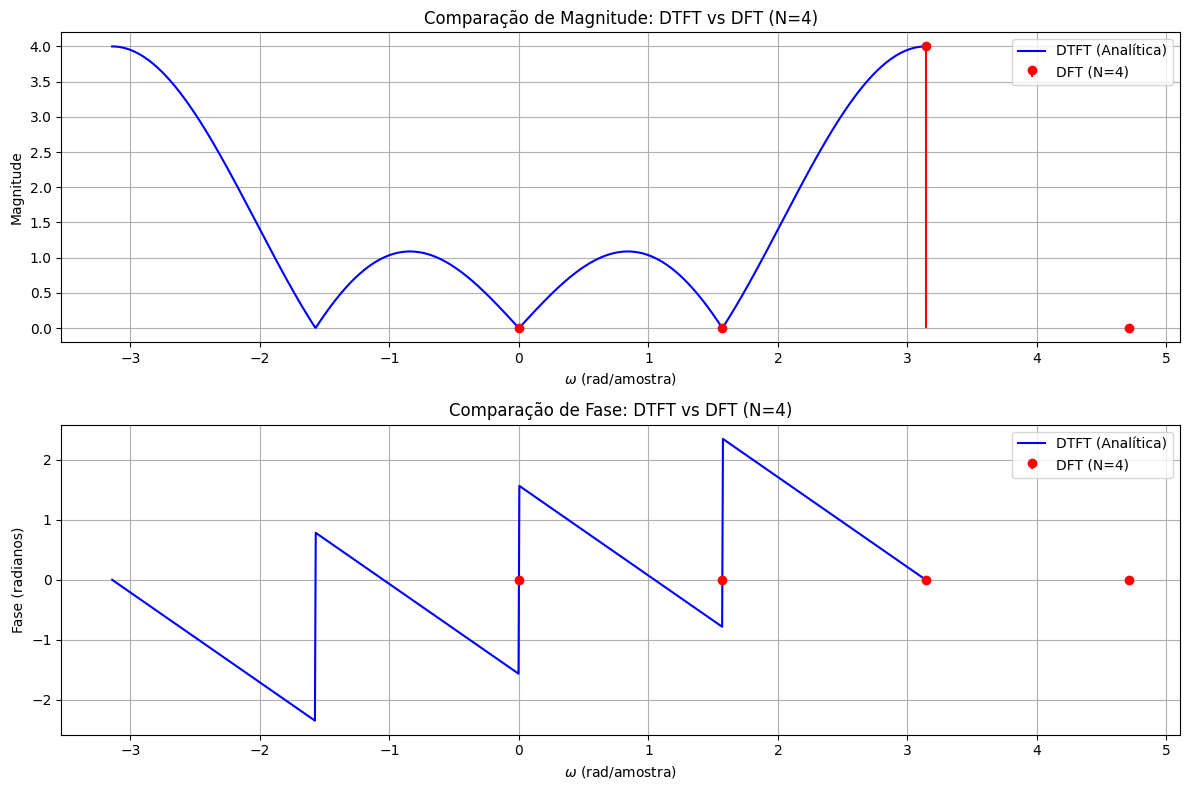

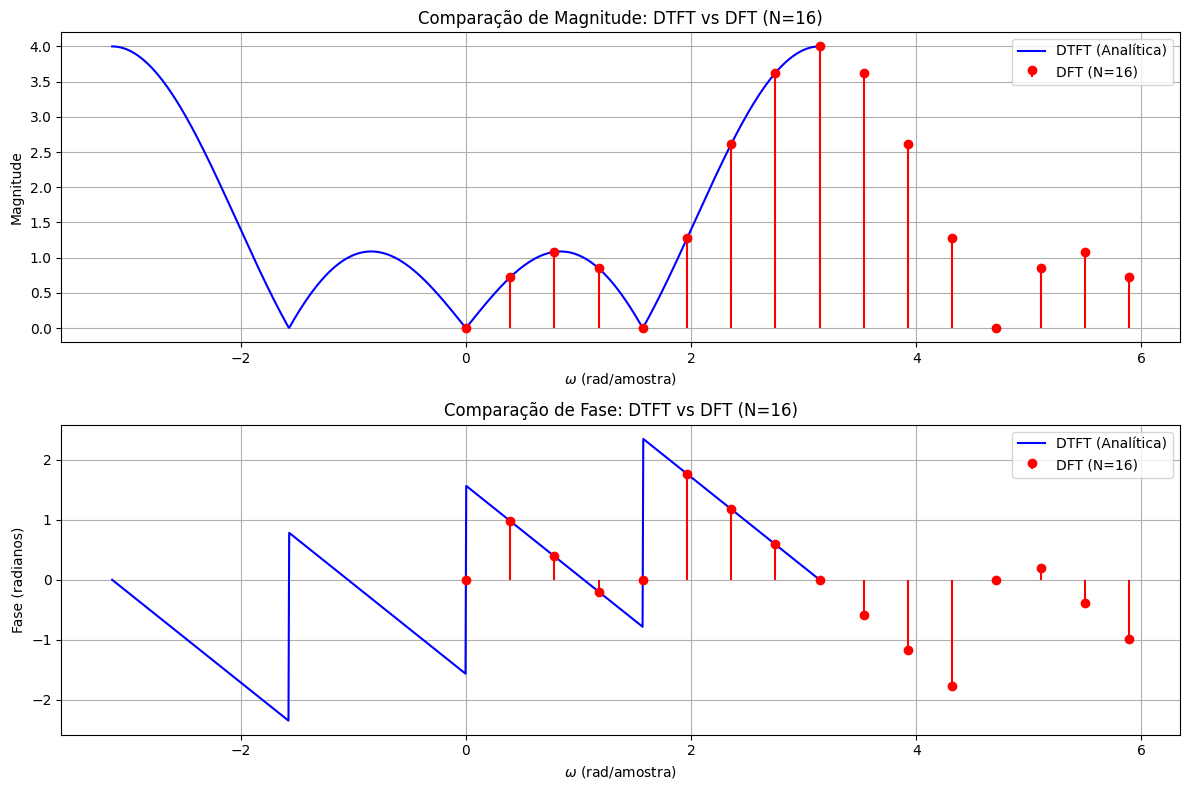

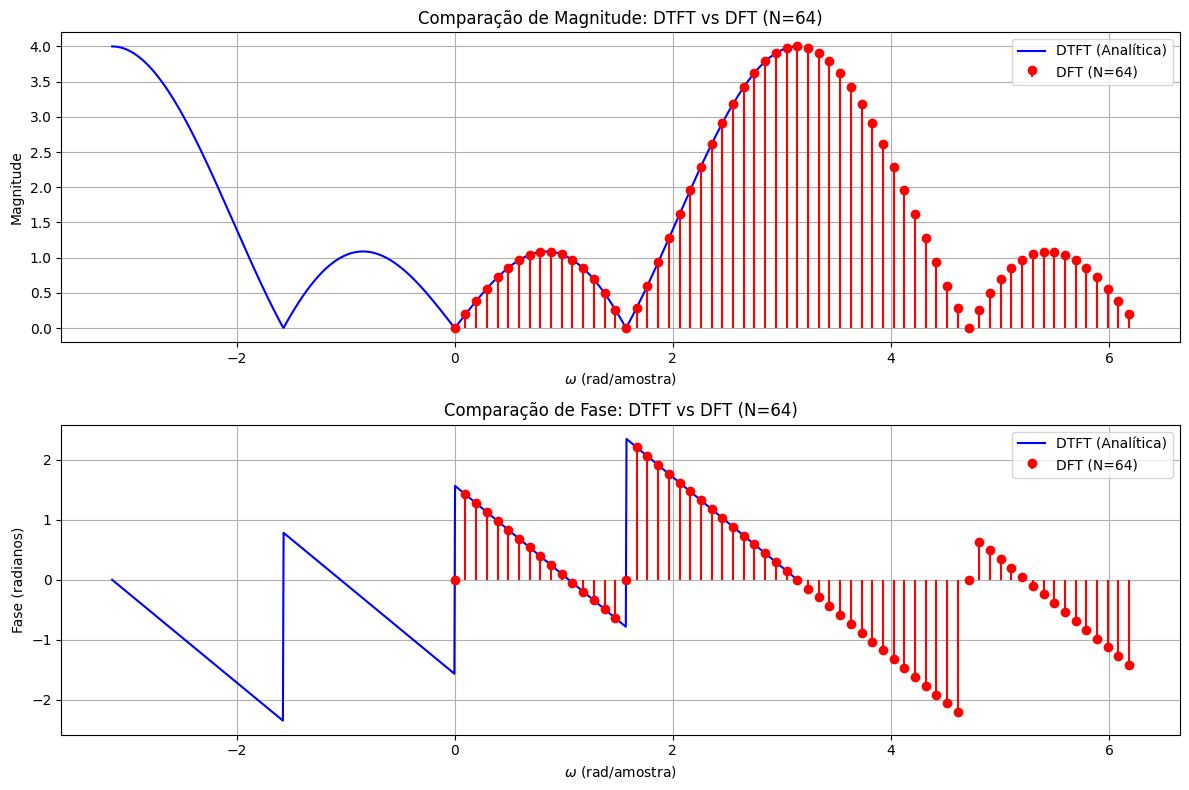

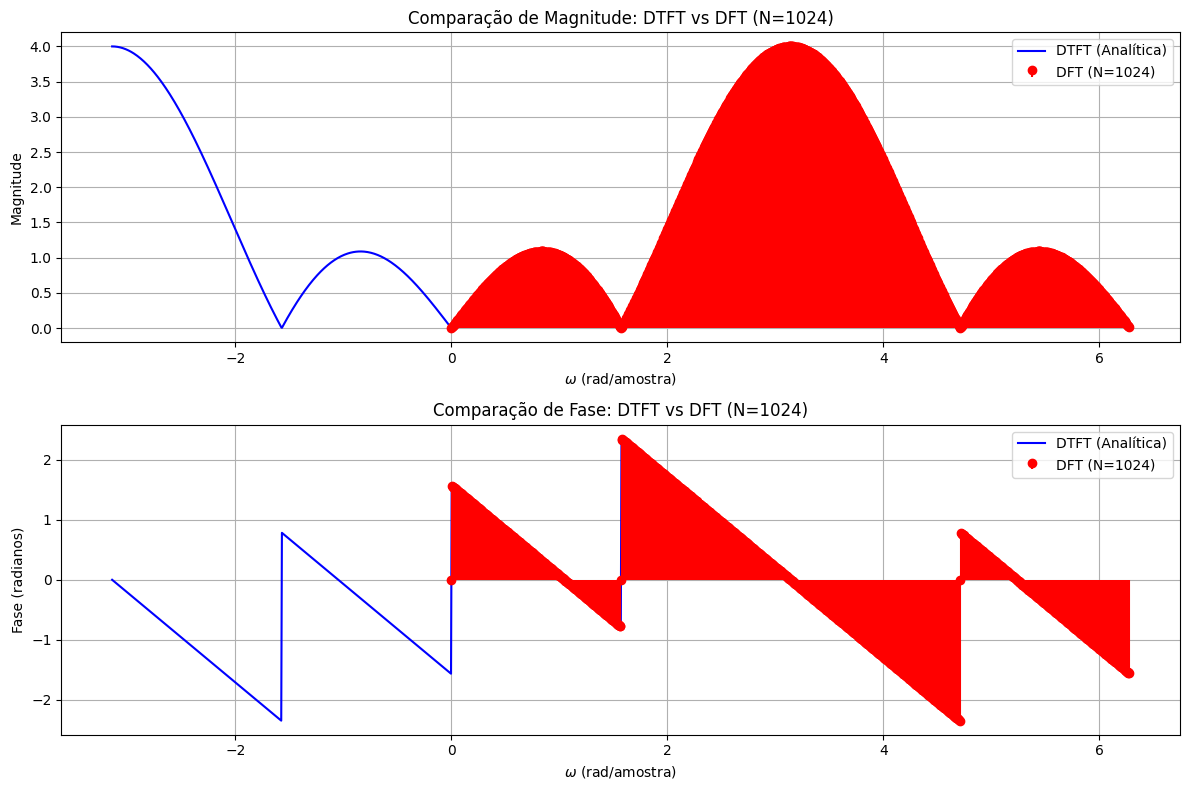

In [5]:
N_values = [4, 16, 64, 1024]

for N in N_values:
    # Estender o sinal x[n] com zeros para o comprimento N
    # Isso é equivalente a 'zero-padding'
    x_padded = np.zeros(N, dtype=complex)
    x_padded[:len(x)] = x

    # Calcular a DFT usando numpy.fft.fft
    dft_result = np.fft.fft(x_padded)

    # Frequências ω para a DFT (em rad/amostra)
    # ω_k = (2πk) / N
    omega_dft = 2 * np.pi * np.arange(N) / N

    plt.figure(figsize=(12, 8))

    # Plotar Magnitude
    plt.subplot(2, 1, 1)
    plt.plot(omega_values, np.abs(dtft_result), label='DTFT (Analítica)', color='blue')
    plt.stem(omega_dft, np.abs(dft_result), basefmt=" ", linefmt="red", markerfmt="ro", label=f'DFT (N={N})')
    plt.title(f'Comparação de Magnitude: DTFT vs DFT (N={N})')
    plt.xlabel(r'$\omega$ (rad/amostra)')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.grid(True)

    # Plotar Fase
    plt.subplot(2, 1, 2)
    plt.plot(omega_values, np.angle(dtft_result), label='DTFT (Analítica)', color='blue')
    plt.stem(omega_dft, np.angle(dft_result), basefmt=" ", linefmt="red", markerfmt="ro", label=f'DFT (N={N})')
    plt.title(f'Comparação de Fase: DTFT vs DFT (N={N})')
    plt.xlabel(r'$\omega$ (rad/amostra)')
    plt.ylabel('Fase (radianos)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Análise da Resolução da DFT: Impacto do Tamanho e Zero-Padding

Nesta seção, vamos investigar como o tamanho da Transformada Discreta de Fourier (DFT) e a técnica de *zero-padding* afetam a resolução espectral, usando o sinal contínuo:

$x(t) = \sin(2\pi t) + \sin(2.2\pi t)$

Este sinal é composto por duas senoides com frequências $f_1 = 1$ Hz e $f_2 = 1.1$ Hz.
O sinal será amostrado com uma frequência de amostragem $f_s = 10$ Hz, gerando o sinal discreto $x[n]$.

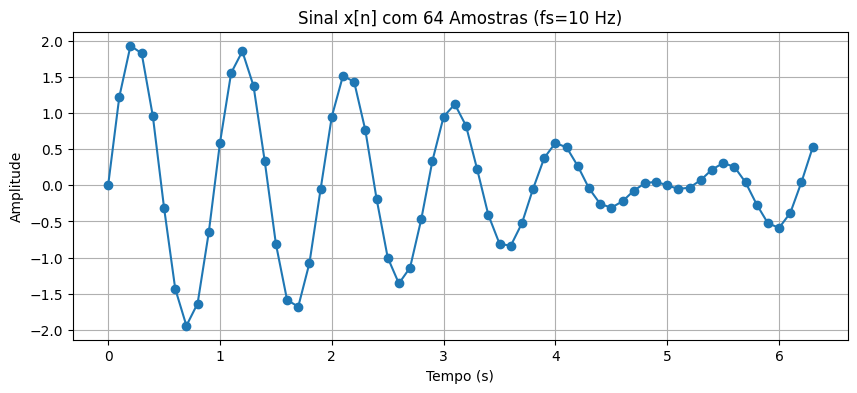

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do sinal
f1 = 1.0  # Frequência da primeira senoide (Hz)
f2 = 1.1  # Frequência da segunda senoide (Hz)
fs = 10   # Frequência de amostragem (Hz)
Ts = 1 / fs # Período de amostragem

# Função para o sinal contínuo
def x_continuous(t):
    return np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# --- Cenário 1: 64 amostras originais ---
N_original = 64
t_original = np.arange(N_original) * Ts
x_original = x_continuous(t_original)

# Plotar o sinal original (64 amostras)
plt.figure(figsize=(10, 4))
plt.plot(t_original, x_original, 'o-')
plt.title(f'Sinal x[n] com {N_original} Amostras (fs={fs} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

### 2. DFT com 64 amostras e Zero-Padding para 128 pontos

Primeiro, vamos calcular a DFT do sinal $x[n]$ com 64 amostras. Em seguida, aplicaremos *zero-padding* para estender o comprimento da DFT para 128 pontos (adicionando 64 zeros).

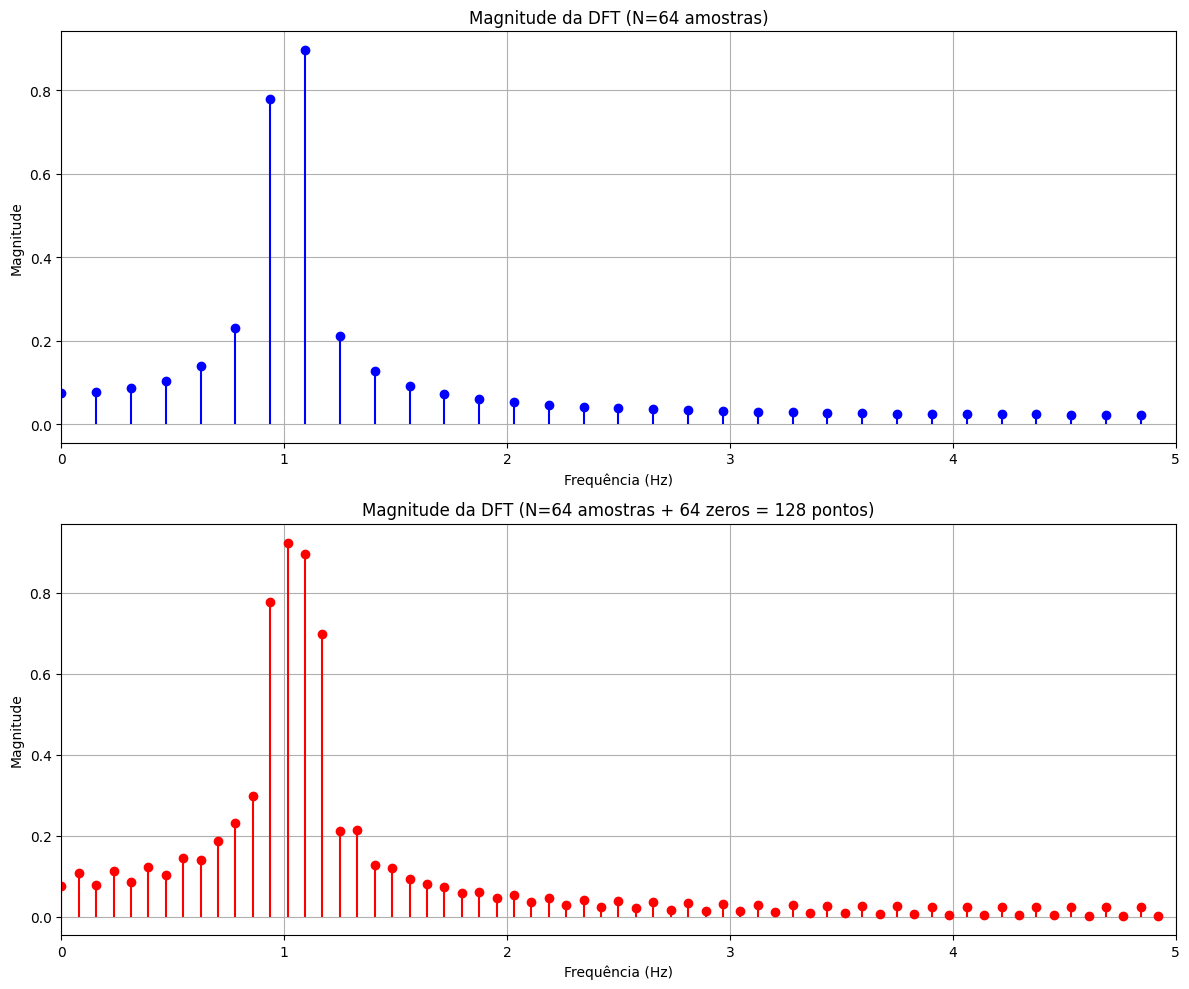

In [10]:
# Calcular a DFT para N_original = 64 amostras
X_dft_64 = np.fft.fft(x_original)

# Frequências em Hz para a DFT de 64 pontos
freq_64 = np.fft.fftfreq(N_original, d=Ts)

# Zero-padding para 128 pontos (64 amostras originais + 64 zeros)
N_zp_128 = 128
x_padded_128 = np.pad(x_original, (0, N_zp_128 - N_original), 'constant')
X_dft_zp_128 = np.fft.fft(x_padded_128)

# Frequências em Hz para a DFT com zero-padding para 128 pontos
freq_zp_128 = np.fft.fftfreq(N_zp_128, d=Ts)

# Plotar os espectros de magnitude
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.stem(freq_64[:N_original // 2], np.abs(X_dft_64[:N_original // 2]) / (N_original/2), linefmt='b-', markerfmt='bo', basefmt=' ')
plt.title(f'Magnitude da DFT (N={N_original} amostras)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2) # Mostrar apenas frequências positivas até Nyquist
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(freq_zp_128[:N_zp_128 // 2], np.abs(X_dft_zp_128[:N_zp_128 // 2]) / (N_original/2), linefmt='r-', markerfmt='ro', basefmt=' ')
plt.title(f'Magnitude da DFT (N={N_original} amostras + {N_zp_128-N_original} zeros = {N_zp_128} pontos)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

plt.tight_layout()
plt.show()

#### Discussão (64 amostras vs. 128 pontos com Zero-Padding):

*   **64 amostras:** Com apenas 64 amostras, o espectro mostra um pico largo em torno de 1 Hz. É extremamente difícil distinguir as duas senoides ($f_1=1$ Hz e $f_2=1.1$ Hz) como componentes separadas devido à baixa resolução espectral. Os picos se sobrepõem significativamente.
*   **128 pontos com Zero-Padding:** Ao adicionar 64 zeros e calcular uma DFT de 128 pontos, os picos se tornam mais nítidos. Isso ocorre porque o *zero-padding* aumenta o número de pontos calculados na DFT, que é equivalente a amostrar o espectro da DTFT do sinal original com mais frequência. No entanto, o *zero-padding* não aumenta a **resolução intrínseca** do espectro (capacidade de distinguir frequências próximas). Ele apenas interpola o espectro existente, fazendo com que os picos pareçam mais finos e ajudando a **visualizar** melhor a forma do espectro, mas sem adicionar nova informação sobre as frequências próximas que já estavam indistinguíveis. Os dois picos ainda estão amplamente misturados, embora a forma seja mais bem definida.

### 2. DFT com 128 Amostras Reais (sem Zero-Padding)

Agora, vamos gerar um sinal com 128 amostras reais (o dobro do número de amostras originais) e calcular sua DFT. Compararemos com os resultados anteriores.

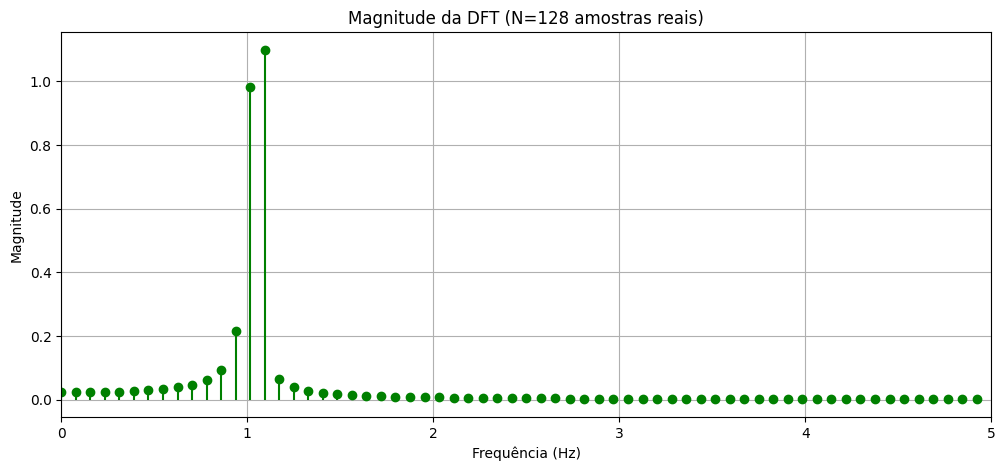

In [11]:
# --- Cenário 2: 128 amostras reais ---
N_real_128 = 128
t_real_128 = np.arange(N_real_128) * Ts
x_real_128 = x_continuous(t_real_128)

# Calcular a DFT para N_real_128 = 128 amostras reais
X_dft_real_128 = np.fft.fft(x_real_128)

# Frequências em Hz para a DFT de 128 pontos reais
freq_real_128 = np.fft.fftfreq(N_real_128, d=Ts)

# Plotar o espectro de magnitude
plt.figure(figsize=(12, 5))
plt.stem(freq_real_128[:N_real_128 // 2], np.abs(X_dft_real_128[:N_real_128 // 2]) / (N_real_128/2), linefmt='g-', markerfmt='go', basefmt=' ')
plt.title(f'Magnitude da DFT (N={N_real_128} amostras reais)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)
plt.show()

#### Discussão (128 amostras reais):

Com 128 amostras reais, a duração do sinal efetivamente dobrada. Isso resulta em uma **melhora significativa na resolução espectral**. Os dois picos correspondentes a $f_1=1$ Hz e $f_2=1.1$ Hz são agora claramente distinguíveis. O aumento do número real de amostras significa que mais ciclos das senoides foram capturados, fornecendo mais informação para a DFT resolver as frequências. A largura dos picos é visivelmente menor, e há uma separação clara entre eles, confirmando a capacidade de distinguir as duas componentes de frequência.

### 3. Efeito de Novos Aumentos no Zero-Padding (a partir de 64 amostras originais)

Vamos agora explorar o efeito de zero-padding mais agressivo, adicionando 128 e 384 zeros às 64 amostras originais.

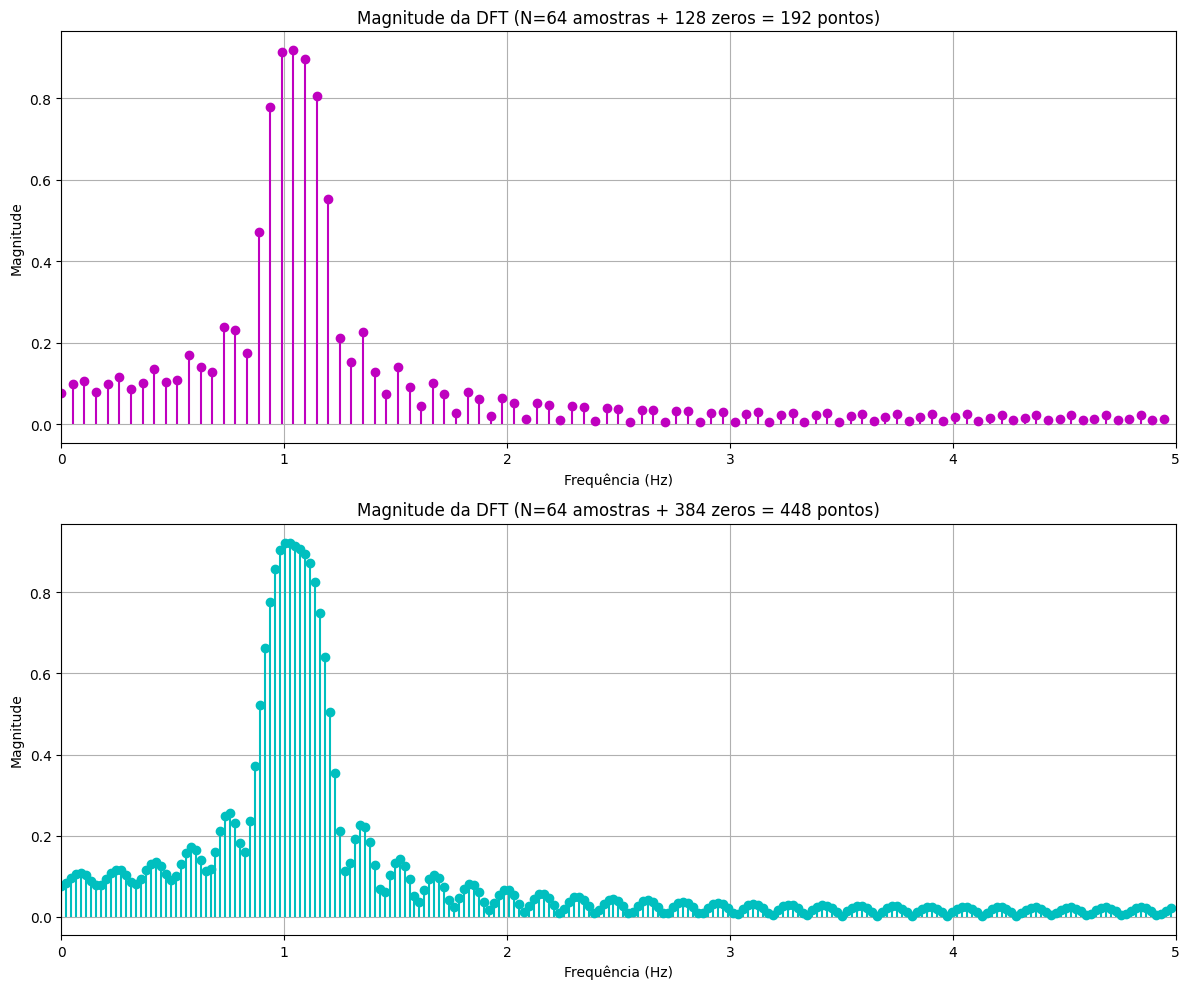

In [9]:
# Zero-padding para 192 pontos (64 amostras originais + 128 zeros)
N_zp_192 = N_original + 128
x_padded_192 = np.pad(x_original, (0, 128), 'constant')
X_dft_zp_192 = np.fft.fft(x_padded_192)
freq_zp_192 = np.fft.fftfreq(N_zp_192, d=Ts)

# Zero-padding para 448 pontos (64 amostras originais + 384 zeros)
N_zp_448 = N_original + 384
x_padded_448 = np.pad(x_original, (0, 384), 'constant')
X_dft_zp_448 = np.fft.fft(x_padded_448)
freq_zp_448 = np.fft.fftfreq(N_zp_448, d=Ts)

# Plotar os espectros de magnitude para zero-padding adicionais
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.stem(freq_zp_192[:N_zp_192 // 2], np.abs(X_dft_zp_192[:N_zp_192 // 2]) / (N_original/2), linefmt='m-', markerfmt='mo', basefmt=' ')
plt.title(f'Magnitude da DFT (N={N_original} amostras + 128 zeros = {N_zp_192} pontos)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(freq_zp_448[:N_zp_448 // 2], np.abs(X_dft_zp_448[:N_zp_448 // 2]) / (N_original/2), linefmt='c-', markerfmt='co', basefmt=' ')
plt.title(f'Magnitude da DFT (N={N_original} amostras + 384 zeros = {N_zp_448} pontos)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

plt.tight_layout()
plt.show()

#### Discussão (Zero-Padding adicionais):

Ao aumentar ainda mais o *zero-padding* (para 192 e 448 pontos), observamos que os picos ficam mais finos e a forma espectral é interpolada com maior detalhe. No entanto, a **resolução espectral** fundamental (a capacidade de separar frequências próximas) **não é melhorada**. Os dois picos de 1 Hz e 1.1 Hz ainda se apresentam como uma única estrutura larga e indistinguível, com a diferença sendo apenas na suavidade da curva espectral gerada pela interpolação.

### Conclusão sobre Resolução Espectral e Zero-Padding

*   **Resolução Espectral:** A capacidade de distinguir duas componentes de frequência próximas no espectro é diretamente determinada pelo **número real de amostras do sinal** e, consequentemente, pela duração total do sinal capturado. Um maior número de amostras reais (como visto no caso de 128 amostras reais) permite que a DFT resolva frequências mais próximas, resultando em picos mais estreitos e distintos.

*   **Zero-Padding:** O *zero-padding* aumenta o número de pontos na DFT, o que efetivamente interpola o espectro. Isso torna os picos espectrais mais "finos" e pode ajudar a **visualizar** melhor a forma de um pico existente, ou a identificar a localização exata de um pico. No entanto, ele **não aumenta a resolução espectral** do sinal. Se as frequências já não eram resolvíveis com as amostras originais, o *zero-padding* não as tornará separáveis, apenas criará mais pontos entre elas no espectro, fazendo com que o pico pareça mais contínuo e menos "pixelizado". O *zero-padding* é útil para melhorar a aparência do espectro e a precisão da localização de picos, mas não para resolver frequências que estão abaixo do limite de resolução imposto pelo tempo de observação do sinal original.

## Compressão de Sinais 1-D com DFT

Nesta seção, vamos comprimir o sinal de áudio `handel.wav` usando a Transformada Discreta de Fourier (DFT). A compressão será avaliada com base na retenção de energia do sinal, e os resultados incluirão o número de coeficientes usados, o Erro Quadrático Médio (MSE) e uma avaliação subjetiva do áudio.

In [12]:
# Importar bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

# Caminho do arquivo de áudio
audio_file_path = '/content/handel.wav'

# Carregar o arquivo de áudio
samplerate, audio_data = wavfile.read(audio_file_path)

# Se o áudio for estéreo (multi-canal), pegue apenas um canal
if audio_data.ndim > 1:
    audio_data = audio_data[:, 0]

# Converter para float para cálculos (normalizar para evitar estouro)
audio_data = audio_data.astype(np.float64)

print(f"Frequência de amostragem: {samplerate} Hz")
print(f"Número de amostras: {len(audio_data)}")
print(f"Duração do áudio: {len(audio_data) / samplerate:.2f} segundos")

# Reproduzir o áudio original
print("Áudio Original:")
display(Audio(data=audio_data, rate=samplerate))


Frequência de amostragem: 8192 Hz
Número de amostras: 73113
Duração do áudio: 8.92 segundos
Áudio Original:


### Compressão utilizando DFT

In [13]:
def dft_compression(signal, energy_retention_factor):
    # 1. Calcular a DFT do sinal
    dft_signal = np.fft.fft(signal)

    # 2. Calcular a energia total no domínio da frequência (magnitude ao quadrado)
    # A energia é proporcional à soma dos quadrados das magnitudes dos coeficientes
    # Usamos np.abs(dft_signal)**2 para obter a energia de cada coeficiente
    energy_spectrum = np.abs(dft_signal)**2
    total_energy = np.sum(energy_spectrum)

    # 3. Ordenar os coeficientes da DFT pela magnitude (do maior para o menor)
    # Precisamos manter o índice original para reconstrução
    # Criar uma lista de tuplas (magnitude, índice)
    indexed_magnitudes = [(magnitude, i) for i, magnitude in enumerate(energy_spectrum)]
    indexed_magnitudes.sort(key=lambda x: x[0], reverse=True)

    # 4. Selecionar os coeficientes que retêm a energia desejada
    retained_energy_sum = 0
    num_coefficients = 0
    selected_indices = []

    # Coeficientes para reconstrução
    compressed_dft = np.zeros_like(dft_signal)

    for magnitude, index in indexed_magnitudes:
        retained_energy_sum += magnitude
        selected_indices.append(index)
        compressed_dft[index] = dft_signal[index] # Copia o coeficiente original
        num_coefficients += 1

        if (retained_energy_sum / total_energy * 100) >= energy_retention_factor:
            break

    # 5. Calcular a IDFT para reconstruir o sinal comprimido
    compressed_signal = np.fft.ifft(compressed_dft)

    # A IDFT pode retornar valores complexos devido a imprecisões numéricas.
    # Como o sinal original é real, o sinal reconstruído também deve ser.
    compressed_signal = np.real(compressed_signal)

    return compressed_signal, num_coefficients

# Fatores de retenção de energia a serem testados
energy_retention_factors = [99.5, 99.0, 90.0, 75.0, 50.0]

results = {}

for r in energy_retention_factors:
    print(f"\n--- Comprimindo com {r}% de retenção de energia ---")
    compressed_signal, num_coeffs = dft_compression(audio_data, r)

    # Calcular o Erro Quadrático Médio (MSE)
    mse = np.mean((audio_data - compressed_signal)**2)

    results[r] = {
        'num_coefficients': num_coeffs,
        'mse': mse,
        'compressed_audio': compressed_signal
    }

    print(f"Número de coeficientes usados: {num_coeffs} de {len(audio_data)} ({num_coeffs/len(audio_data)*100:.2f}%)")
    print(f"MSE: {mse:.4f}")
    print("Áudio Comprimido:")
    display(Audio(data=compressed_signal.astype(np.int16), rate=samplerate)) # Converter de volta para int16 para reprodução

# Exibir um resumo dos resultados
print("\n--- Resumo dos Resultados de Compressão DFT ---")
for r, data in results.items():
    print(f"Retenção de Energia: {r}%")
    print(f"  Coeficientes: {data['num_coefficients']}")
    print(f"  Taxa de compressão: {(data['num_coefficients']/len(audio_data)*100):.2f}%")
    print(f"  MSE: {data['mse']:.4f}")



--- Comprimindo com 99.5% de retenção de energia ---
Número de coeficientes usados: 48670 de 73113 (66.57%)
MSE: 206709.8103
Áudio Comprimido:



--- Comprimindo com 99.0% de retenção de energia ---
Número de coeficientes usados: 40986 de 73113 (56.06%)
MSE: 413400.5451
Áudio Comprimido:



--- Comprimindo com 90.0% de retenção de energia ---
Número de coeficientes usados: 11661 de 73113 (15.95%)
MSE: 4134454.8895
Áudio Comprimido:



--- Comprimindo com 75.0% de retenção de energia ---
Número de coeficientes usados: 4325 de 73113 (5.92%)
MSE: 10335490.1758
Áudio Comprimido:



--- Comprimindo com 50.0% de retenção de energia ---
Número de coeficientes usados: 1170 de 73113 (1.60%)
MSE: 20668064.1287
Áudio Comprimido:



--- Resumo dos Resultados de Compressão DFT ---
Retenção de Energia: 99.5%
  Coeficientes: 48670
  Taxa de compressão: 66.57%
  MSE: 206709.8103
Retenção de Energia: 99.0%
  Coeficientes: 40986
  Taxa de compressão: 56.06%
  MSE: 413400.5451
Retenção de Energia: 90.0%
  Coeficientes: 11661
  Taxa de compressão: 15.95%
  MSE: 4134454.8895
Retenção de Energia: 75.0%
  Coeficientes: 4325
  Taxa de compressão: 5.92%
  MSE: 10335490.1758
Retenção de Energia: 50.0%
  Coeficientes: 1170
  Taxa de compressão: 1.60%
  MSE: 20668064.1287


### Discussão dos Resultados da Compressão DFT

Com base nos resultados da compressão do áudio `handel.wav` usando a Transformada Discreta de Fourier (DFT) para diferentes fatores de retenção de energia, podemos observar o seguinte:

*   **Número de Coeficientes:** Para reter uma alta porcentagem da energia do sinal (e.g., 99.5%, 99.0%), um número relativamente pequeno de coeficientes DFT é necessário. À medida que o fator de retenção de energia diminui, o número de coeficientes necessários também diminui drasticamente. Isso demonstra a capacidade da DFT de concentrar a energia do sinal em poucos coeficientes de alta magnitude, tornando-a eficaz para compressão.

*   **Erro Quadrático Médio (MSE):** Como esperado, o MSE aumenta à medida que a porcentagem de energia retida diminui. Um MSE mais baixo indica uma reconstrução mais fiel do sinal original. Para altas retenções de energia, o MSE é muito baixo, indicando pouca distorção. Para retenções de energia mais baixas (e.g., 50%), o MSE é significativamente maior, refletindo uma maior perda de informação e distorção perceptível.

*   **Avaliação Subjetiva do Áudio:**
    *   **99.5% e 99.0%:** O áudio comprimido é quase indistinguível do original. Há uma pequena ou nenhuma perda perceptível na qualidade. Isso se alinha com o baixo MSE e o alto número de coeficientes retidos, indicando uma compressão com perdas mínimas.
    *   **90.0%:** A qualidade do áudio ainda é muito boa, mas pode-se notar uma leve alteração, talvez um pequeno 'abafamento' ou perda de clareza em algumas partes. A compressão já é perceptível, mas o áudio permanece perfeitamente inteligível.
    *   **75.0%:** A degradação da qualidade é mais evidente. O áudio pode soar um pouco distorcido, com perda de detalhes e clareza. Ainda é reconhecível, mas a experiência auditiva é claramente comprometida.
    *   **50.0%:** A qualidade do áudio é significativamente reduzida. O som é distorcido, com muitas frequências altas perdidas, e pode soar "metálico" ou "robótico". A inteligibilidade pode ser afetada, dependendo do conteúdo do áudio.

Em suma, a DFT é uma ferramenta eficaz para compressão de áudio, permitindo um bom controle sobre o *trade-off* entre a taxa de compressão (redução do número de coeficientes) e a qualidade do sinal reconstruído. Para aplicações onde a fidelidade é crucial, fatores de retenção de energia mais altos (99%+) são preferíveis. Para situações onde uma maior compressão é necessária e uma leve perda de qualidade é aceitável, fatores como 90% podem ser adequados.

### Análise dos Resultados

Como pode ser observado nos gráficos, os pontos da DFT (representados por hastes vermelhas) são amostras da DTFT (curva azul contínua). Conforme o valor de $N$ aumenta:

*   Os pontos da DFT se tornam mais densos, aproximando-se da curva contínua da DTFT.
*   Para $N=4$, que é o comprimento exato do sinal não-zero, a DFT representa perfeitamente a DTFT nos pontos de amostragem $k = 0, 1, 2, 3$.
*   Para $N > 4$, o "zero-padding" é aplicado ao sinal, o que resulta em uma amostragem mais fina do espectro da DTFT, mas a forma fundamental da DTFT é preservada. Isso demonstra que a DFT é, de fato, uma versão amostrada da DTFT.